In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

In [2]:
from pathlib import Path

import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns

from patient_simulator.misc.plotting import plot_model_size_metrics_with_uncertainty

sns.set_theme(style="whitegrid")

csv_path = Path("../results/llm_feasibility/feasibility_scores.csv")
df = pd.read_csv(csv_path)

In [ ]:
# exclude models with outliers or slow apis
exclude_models = [
    "qwen/qwen3.5-35b-a3b",
    "moonshotai/kimi-k2.5",
    "openai/gpt-oss-120b",
    "mistralai/mistral-small-3.2-24b-instruct",
]

df = df[~df["model"].isin(exclude_models)].copy()

SMALL_MODELS = {
    "qwen/qwen3-8b",
    "mistralai/ministral-8b-2512",
    "mistralai/ministral-14b-2512",
    "openai/gpt-oss-20b",
}

model_display_name = {
    "deepseek/deepseek-v3.2": "DeepSeek V3.2",
    "minimax/minimax-m2.5": "MiniMax M2.5",
    "moonshotai/kimi-k2.5": "Kimi K2.5",
    "anthropic/claude-opus-4.6": "Claude Opus 4.6",
    "openai/gpt-5.2": "GPT-5.2",
    "openai/gpt-oss-120b": "GPT-OSS 120B",
    "openai/gpt-oss-20b": "GPT-OSS 20B",
    "mistralai/mistral-small-3.2-24b-instruct": "Mistral Small 24B",
    "mistralai/ministral-8b-2512": "Ministral 8B",
    "mistralai/ministral-14b-2512": "Ministral 14B",
    "qwen/qwen3.5-35b-a3b": "Qwen 3.5 35B",
    "qwen/qwen3-8b": "Qwen 3 8B",
    "google/gemini-3-flash-preview": "Gemini 3 Flash",
    "google/gemini-3.1-flash-lite-preview": "Gemini 3.1 Flash Lite",
}

model_size_b = {
    "deepseek/deepseek-v3.2": 671,
    "minimax/minimax-m2.5": 456,
    "moonshotai/kimi-k2.5": 32,
    "google/gemini-3-flash-preview": 120,
    "google/gemini-3.1-flash-lite-preview": 100,
    "anthropic/claude-opus-4.6": 220,
    "openai/gpt-5.2": 300,
    "openai/gpt-oss-120b": 120,
    "mistralai/mistral-small-3.2-24b-instruct": 24,
    "qwen/qwen3.5-35b-a3b": 35,
    "mistralai/ministral-8b-2512": 8,
    "mistralai/ministral-14b-2512": 14,
    "qwen/qwen3-8b": 8,
    "openai/gpt-oss-20b": 20,
}

model_provider = {
    "deepseek/deepseek-v3.2": "deepseek",
    "minimax/minimax-m2.5": "minimax",
    "moonshotai/kimi-k2.5": "moonshot",
    "anthropic/claude-opus-4.6": "anthropic",
    "openai/gpt-5.2": "openai",
    "openai/gpt-oss-120b": "openai",
    "openai/gpt-oss-20b": "openai",
    "mistralai/mistral-small-3.2-24b-instruct": "mistralai",
    "mistralai/ministral-8b-2512": "mistralai",
    "mistralai/ministral-14b-2512": "mistralai",
    "qwen/qwen3.5-35b-a3b": "qwen",
    "qwen/qwen3-8b": "qwen",
    "google/gemini-3-flash-preview": "google",
    "google/gemini-3.1-flash-lite-preview": "google",
}

provider_base_colors = {
    "mistralai": "#d4761a",
    "google": "#1a73e8",
    "openai": "#10a37f",
    "anthropic": "#c96442",
    "deepseek": "#1e40af",
    "minimax": "#7c3aed",
    "moonshot": "#0891b2",
    "qwen": "#b91c1c",
}

df["display_name"] = df["model"].map(model_display_name).fillna(df["model"])
df["model_size_b"] = df["model"].map(model_size_b)
df["provider"] = df["model"].map(model_provider)

missing_sizes = sorted(df.loc[df["model_size_b"].isna(), "model"].unique())
if missing_sizes:
    print("Missing size estimates for:")
    for model in missing_sizes:
        print(" -", model)

provider_model_sizes = (
    df[["model", "provider", "model_size_b", "display_name"]]
    .drop_duplicates("model")
    .dropna(subset=["model_size_b"])
)

name_palette = {}
for provider, group in provider_model_sizes.groupby("provider"):
    base_rgb = mcolors.to_rgb(provider_base_colors.get(provider, "#888888"))
    for name in group["display_name"]:
        name_palette[name] = base_rgb

_hatch_cycle = ["", "///", "xxx", "---"]
name_hatch = {}
for _provider, _group in provider_model_sizes.groupby("provider"):
    _sorted = _group.sort_values("model_size_b")["display_name"].tolist()
    for _i, _name in enumerate(_sorted):
        name_hatch[_name] = _hatch_cycle[_i % len(_hatch_cycle)]

df.head()

,model,meta_llm_score,conv_llm_score,runtime_seconds,test_downplay,test_downplay_resp,test_emotional_state,test_emotional_state_resp,test_relevant_field_classification,test_relevant_field_classification_resp,test_basic_simulation,test_basic_simulation_resp,test_personality_steering,test_personality_steering_resp,display_name,model_size_b,provider
0,minimax/minimax-m2.5,0.833333,0.5,183.615684,1.0,"[""drinks some vodka"", ""pain is pretty bad"", ""s...",1.0,"[""The patient is in acute distress, repeatedly...",0.500000,"[""present_illness_negative, present_illness_po...",1.0,"[""I have chest pain that started last night wh...",0.0,"{""default_turn1"": ""Chest pain. Started last ni...",MiniMax M2.5,456,minimax
2,google/gemini-3-flash-preview,0.814815,0.8,29.726644,1.0,"[""enjoys a few drinks"", ""hurts a bit"", ""feelin...",1.0,"[""The patient exhibits high anxiety through fr...",0.444444,"[""pain, present_illness_negative, present_illn...",1.0,"[""I've been having sharp chest pain on my left...",0.6,"{""default_turn1"": ""Chest pain. It started last...",Gemini 3 Flash,120,google
3,anthropic/claude-opus-4.6,0.814815,0.9,118.708793,1.0,"[""has a few drinks daily"", ""feeling a bit unco...",1.0,"[""The patient is anxious and catastrophizing, ...",0.444444,"[""pain, present_illness_negative, present_illn...",1.0,"[""I've been having chest pain since last night...",0.8,"{""default_turn1"": ""Chest pain. It started last...",Claude Opus 4.6,220,anthropic
4,openai/gpt-5.2,0.814815,0.9,74.007869,1.0,"[""has a little liquor most days"", ""pain is pre...",1.0,"[""They speak in short, broken sentences and re...",0.444444,"[""pain, present_illness_positive"", ""pain, pres...",1.0,"[""I\u2019ve had sharp pain on the left side of...",0.8,"{""default_turn1"": ""I came in because I have ch...",GPT-5.2,300,openai
5,deepseek/deepseek-v3.2,0.814815,0.7,74.637520,1.0,"[""has a drink every day"", ""deals with some pai...",1.0,"[""The patient, a 42-year-old with chest pain, ...",0.444444,"[""present_illness_positive"", ""pain, present_il...",1.0,"[""I've had chest pain on my left side since la...",0.4,"{""default_turn1"": ""Chest pain. Started last ni...",DeepSeek V3.2,671,deepseek


In [4]:
meta_cols = [
    "test_downplay",
    "test_emotional_state",
    "test_relevant_field_classification",
]
conv_cols = [
    "test_basic_simulation",
    "test_personality_steering",
]

metric_display_names = {
    "test_downplay": "Downplay",
    "test_emotional_state": "Emotional State",
    "test_relevant_field_classification": "Field Classification",
    "test_basic_simulation": "Basic Simulation",
    "test_personality_steering": "Personality Steering",
    "meta_llm_score": "Meta Score",
    "conv_llm_score": "Conv. Score",
}

all_score_cols = [*meta_cols, "meta_llm_score", *conv_cols, "conv_llm_score"]

plot_df = (
    df.dropna(subset=["model_size_b"])
    .groupby(["model", "display_name", "model_size_b"], as_index=False)[all_score_cols]
    .mean()
    .sort_values("model_size_b")
)

plot_df[["display_name", "model_size_b", *all_score_cols]]

,display_name,model_size_b,test_downplay,test_emotional_state,test_relevant_field_classification,meta_llm_score,test_basic_simulation,test_personality_steering,conv_llm_score
6,Ministral 8B,8,0.611111,1.000000,0.500000,0.703704,1.0,0.466667,0.733333
9,Qwen 3 8B,8,0.666667,0.833333,0.462963,0.654321,1.0,0.433333,0.716667
5,Ministral 14B,14,0.866667,1.000000,0.500000,0.788889,1.0,0.520000,0.760000
8,GPT-OSS 20B,20,0.733333,1.000000,0.427778,0.720370,1.0,0.280000,0.640000
3,Gemini 3.1 Flash Lite,100,1.000000,1.000000,0.444444,0.814815,1.0,0.633333,0.816667
2,Gemini 3 Flash,120,1.000000,1.000000,0.444444,0.814815,1.0,0.400000,0.700000
0,Claude Opus 4.6,220,1.000000,1.000000,0.444444,0.814815,1.0,0.733333,0.866667
7,GPT-5.2,300,0.944444,1.000000,0.444444,0.796296,1.0,0.600000,0.800000
4,MiniMax M2.5,456,0.833333,0.944444,0.527778,0.768519,1.0,0.566667,0.783333
1,DeepSeek V3.2,671,1.000000,1.000000,0.444444,0.814815,1.0,0.533333,0.766667


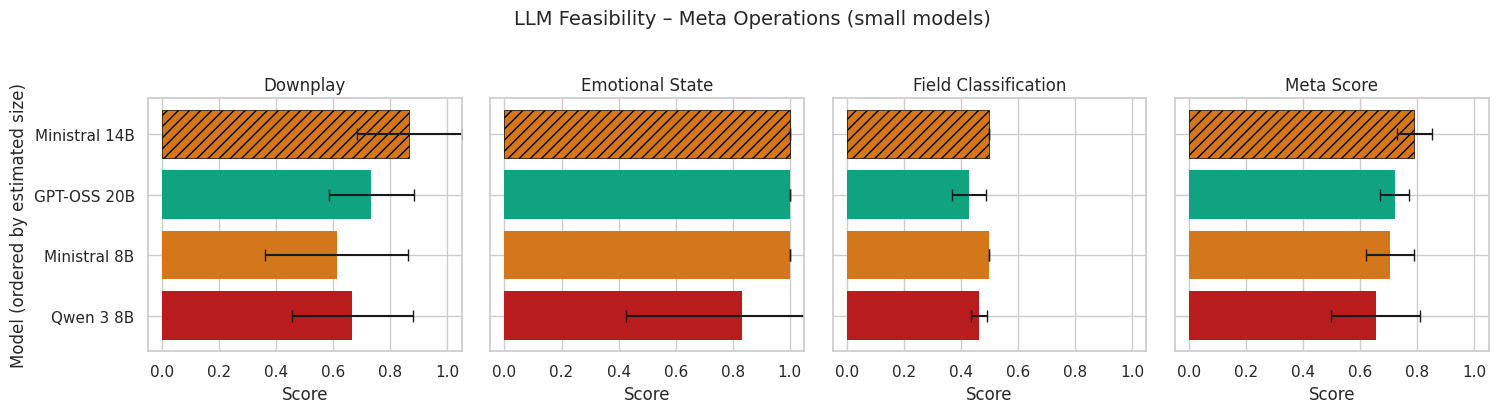

In [5]:
_meta_order = (
    df[df["model"].isin(SMALL_MODELS)]
    .groupby("display_name")["meta_llm_score"]
    .mean()
    .sort_values()
    .index.tolist()
)

plot_model_size_metrics_with_uncertainty(
    df=df[df["model"].isin(SMALL_MODELS)],
    metric_cols=meta_cols,
    summary_col="meta_llm_score",
    title="LLM Feasibility – Meta Operations (small models)",
    palette=name_palette,
    metric_display_names=metric_display_names,
    model_order=_meta_order,
    hatch_map=name_hatch,
)

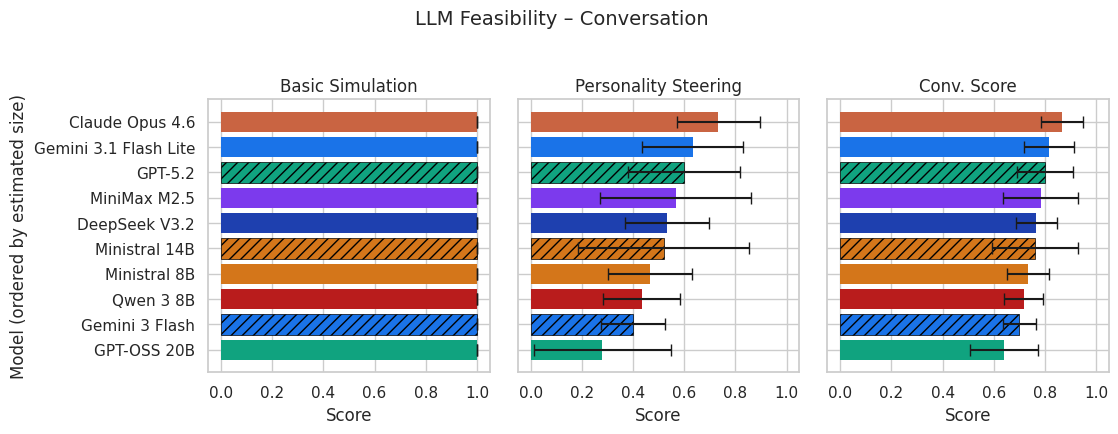

In [6]:
_conv_order = (
    df.groupby("display_name")["conv_llm_score"].mean().sort_values().index.tolist()
)

plot_model_size_metrics_with_uncertainty(
    df=df,
    metric_cols=conv_cols,
    summary_col="conv_llm_score",
    title="LLM Feasibility – Conversation",
    palette=name_palette,
    metric_display_names=metric_display_names,
    model_order=_conv_order,
    hatch_map=name_hatch,
)

In [7]:
_table_styles = [
    {
        "selector": "caption",
        "props": [
            ("font-weight", "bold"),
            ("font-size", "11pt"),
            ("text-align", "left"),
            ("padding-bottom", "4px"),
        ],
    },
    {
        "selector": "thead tr th",
        "props": [
            ("border-top", "2px solid black"),
            ("border-bottom", "1px solid black"),
            ("padding", "4px 10px"),
            ("text-align", "center"),
            ("background", "white"),
            ("font-weight", "bold"),
        ],
    },
    {"selector": "td", "props": [("padding", "3px 10px"), ("text-align", "center")]},
    {
        "selector": "tbody tr:last-child td",
        "props": [("border-bottom", "2px solid black")],
    },
]


def _bold_max(s):
    return ["font-weight: bold" if v == s.max() else "" for v in s]


# Meta LLM table – small models only
_meta_score_cols = [*meta_cols, "meta_llm_score"]
_meta_display_cols = [metric_display_names[c] for c in meta_cols] + ["Avg. Score"]
_meta_col_rename = {
    "display_name": "Model",
    **{c: metric_display_names[c] for c in meta_cols},
    "meta_llm_score": "Avg. Score",
}
_meta_tbl = (
    plot_df[plot_df["model"].isin(SMALL_MODELS)][["display_name", *_meta_score_cols]]
    .sort_values("meta_llm_score", ascending=False)
    .rename(columns=_meta_col_rename)
)
display(
    _meta_tbl.style.format({c: "{:.3f}" for c in _meta_display_cols})
    .apply(_bold_max, subset=_meta_display_cols)
    .hide(axis="index")
    .set_caption("Meta LLM Scores")
    .set_table_styles(_table_styles)
)

# Conv LLM table – all models, sorted by conv score
_conv_score_cols = [*conv_cols, "conv_llm_score"]
_conv_display_cols = [metric_display_names[c] for c in conv_cols] + ["Avg. Score"]
_conv_col_rename = {
    "display_name": "Model",
    **{c: metric_display_names[c] for c in conv_cols},
    "conv_llm_score": "Avg. Score",
}
_conv_tbl = (
    plot_df[["display_name", *_conv_score_cols]]
    .sort_values("conv_llm_score", ascending=False)
    .rename(columns=_conv_col_rename)
)
display(
    _conv_tbl.style.format({c: "{:.3f}" for c in _conv_display_cols})
    .apply(_bold_max, subset=_conv_display_cols)
    .hide(axis="index")
    .set_caption("Conversational LLM Scores")
    .set_table_styles(_table_styles)
)

Model,Downplay,Emotional State,Field Classification,Avg. Score
Ministral 14B,0.867,1.000,0.500,0.789
GPT-OSS 20B,0.733,1.000,0.428,0.720
Ministral 8B,0.611,1.000,0.500,0.704
Qwen 3 8B,0.667,0.833,0.463,0.654


Model,Basic Simulation,Personality Steering,Avg. Score
Claude Opus 4.6,1.000,0.733,0.867
Gemini 3.1 Flash Lite,1.000,0.633,0.817
GPT-5.2,1.000,0.600,0.800
MiniMax M2.5,1.000,0.567,0.783
DeepSeek V3.2,1.000,0.533,0.767
Ministral 14B,1.000,0.520,0.760
Ministral 8B,1.000,0.467,0.733
Qwen 3 8B,1.000,0.433,0.717
Gemini 3 Flash,1.000,0.400,0.700
GPT-OSS 20B,1.000,0.280,0.640


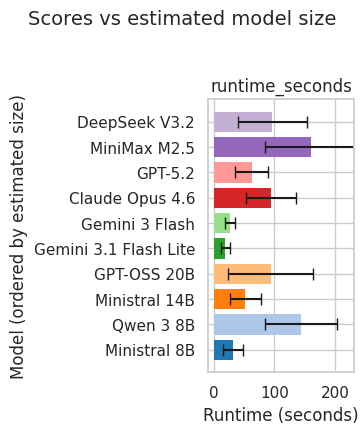

In [8]:
plot_model_size_metrics_with_uncertainty(
    df=df, metric_cols=["runtime_seconds"], y_label="Runtime (seconds)"
)